# Binary latent fork results table

This notebook renders the main binary latent fork aggregate results table as PNG and PDF only.

It filters `metrics.csv` to `region == 'all'` and `context_bucket == 'all'`, giving one row per model.


In [3]:
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path("/scratch2/ij292/tnp-crps").resolve()
os.chdir(REPO_ROOT)

EVAL_DIR = REPO_ROOT / "results/synthetic_1d/binary_latent_fork_eval"
# EVAL_DIR = REPO_ROOT / "results/synthetic_1d/binary_latent_fork_eval_mixctx_full"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = EVAL_DIR / "metrics.csv"
metrics = pd.read_csv(metrics_path)

print("Loaded:", metrics_path)
print("Shape before filtering:", metrics.shape)
print("Columns:", list(metrics.columns))

# Main aggregate table: one row per model.
metrics = metrics[
    (metrics["region"] == "all")
    & (metrics["context_bucket"] == "all")
].copy()

print("Shape after filtering:", metrics.shape)
display(metrics)

assert metrics.shape[0] == 3, f"Expected 3 aggregate rows, got {metrics.shape[0]}"

Loaded: /scratch2/ij292/tnp-crps/results/synthetic_1d/binary_latent_fork_eval/metrics.csv
Shape before filtering: (27, 165)
Columns: ['model_name', 'eval_set', 'region', 'context_bucket', 'num_eval_samples', 'numel', 'rmse_pooled', 'crps', 'energy_score', 'ensemble_spread', 'spread_skill_ratio', 'sample_diversity_offdiag', 'coverage_50', 'coverage_80', 'coverage_90', 'coverage_95', 'width_50', 'width_80', 'width_90', 'width_95', 'checkpoint_path', 'sse', 'crps_sum', 'var_sum', 'diversity_sum', 'energy_score_sum', 'energy_score_num_tasks', 'coverage_count_50', 'width_sum_50', 'coverage_count_80', 'width_sum_80', 'coverage_count_90', 'width_sum_90', 'coverage_count_95', 'width_sum_95', 'rank_000', 'rank_001', 'rank_002', 'rank_003', 'rank_004', 'rank_005', 'rank_006', 'rank_007', 'rank_008', 'rank_009', 'rank_010', 'rank_011', 'rank_012', 'rank_013', 'rank_014', 'rank_015', 'rank_016', 'rank_017', 'rank_018', 'rank_019', 'rank_020', 'rank_021', 'rank_022', 'rank_023', 'rank_024', 'rank_0

,model_name,eval_set,region,context_bucket,num_eval_samples,numel,rmse_pooled,crps,energy_score,ensemble_spread,...,rank_055_prob,rank_056_prob,rank_057_prob,rank_058_prob,rank_059_prob,rank_060_prob,rank_061_prob,rank_062_prob,rank_063_prob,rank_064_prob
0,binary_latent_fork_dropout_crps_m4_p010,binary_latent_fork,all,all,64,524288,1.458237,0.583705,11.472074,1.443442,...,0.015451,0.015724,0.015993,0.016190,0.016380,0.016420,0.016438,0.015821,0.015175,0.013563
9,binary_latent_fork_gaussian_tnp_nll,binary_latent_fork,all,all,64,524288,1.458771,0.631374,11.475571,1.445011,...,0.030079,0.029533,0.026596,0.023611,0.020048,0.015944,0.012796,0.010118,0.008665,0.007826
18,binary_latent_fork_stochln_crps_m4,binary_latent_fork,all,all,64,524288,1.460967,0.585621,9.361974,1.443476,...,0.016254,0.015995,0.015924,0.015699,0.015297,0.016039,0.014898,0.015003,0.015770,0.015352


In [4]:
MODEL_RENAME = {
    "binary_latent_fork_gaussian_tnp_nll": "Gaussian TNP NLL",
    "binary_latent_fork_dropout_crps_m4_p010": "Dropout CRPS M4\np=0.10",
    "binary_latent_fork_stochln_crps_m4": "StochLN CRPS M4",
}

MODEL_ORDER = [
    "Gaussian TNP NLL",
    "Dropout CRPS M4\np=0.10",
    "StochLN CRPS M4",
]


def build_results_table(metrics):
    df = metrics.copy()

    df["Model"] = df["model_name"].map(MODEL_RENAME).fillna(df["model_name"])
    df["Model"] = pd.Categorical(df["Model"], categories=MODEL_ORDER, ordered=True)
    df = df.sort_values("Model")
    df["Model"] = df["Model"].astype(str)

    table = pd.DataFrame(
        {
            "Model": df["Model"],
            "RMSE ↓": df["rmse_pooled"],
            "CRPS ↓": df["crps"],
            "Energy ↓": df["energy_score"],
            "SSR ≈ 1": df["spread_skill_ratio"],
            "Cov90": df["coverage_90"],
            "Cov95": df["coverage_95"],
            "Width90 ↓": df["width_90"],
            "Width95 ↓": df["width_95"],
        }
    )

    for col in table.columns:
        if col != "Model":
            table[col] = table[col].map(lambda x: f"{float(x):.3f}")

    return table


table_df = build_results_table(metrics)
display(table_df)

,Model,RMSE ↓,CRPS ↓,Energy ↓,SSR ≈ 1,Cov90,Cov95,Width90 ↓,Width95 ↓
9,Gaussian TNP NLL,1.459,0.631,11.476,0.998,0.918,0.958,3.321,3.887
0,Dropout CRPS M4\np=0.10,1.458,0.584,11.472,0.998,0.876,0.927,2.660,2.835
18,StochLN CRPS M4,1.461,0.586,9.362,0.996,0.875,0.924,2.666,2.833


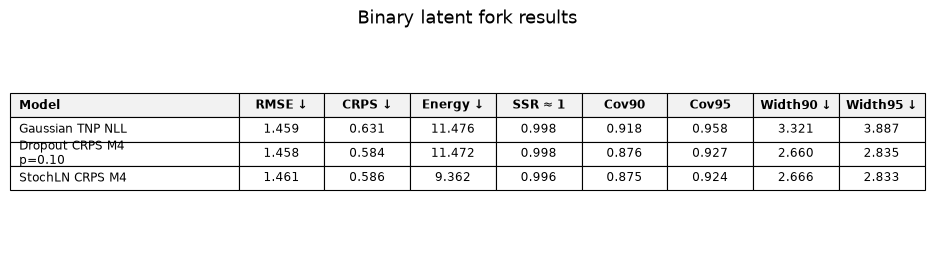

Wrote: /scratch2/ij292/tnp-crps/results/synthetic_1d/binary_latent_fork_eval/binary_latent_fork_results_table.png
Wrote: /scratch2/ij292/tnp-crps/results/synthetic_1d/binary_latent_fork_eval/binary_latent_fork_results_table.pdf


In [11]:
def save_table_png_pdf(
    table_df,
    *,
    title="Binary latent fork results",
    output_stem="binary_latent_fork_results_table",
):
    n_rows, n_cols = table_df.shape

    fig_width = 11.8
    fig_height = 1.45 + 0.42 * n_rows

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")
    ax.set_title(title, fontsize=13, pad=10)

    model_col_width = 0.25
    remaining_width = 1.0 - model_col_width
    metric_col_width = remaining_width / (n_cols - 1)
    col_widths = [model_col_width] + [metric_col_width] * (n_cols - 1)

    tbl = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        colWidths=col_widths,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.3)
    tbl.scale(1.0, 1.45)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("black")
        cell.set_linewidth(0.8)

        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#f2f2f2")

        if col == 0:
            cell.set_text_props(ha="left")
            cell.PAD = 0.04

    png_path = EVAL_DIR / f"{output_stem}.png"
    pdf_path = EVAL_DIR / f"{output_stem}.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight", pad_inches=0.12)
    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.12)
    plt.show()

    print("Wrote:", png_path)
    print("Wrote:", pdf_path)


save_table_png_pdf(table_df)

Split table source shape: (6, 165)


,model_name,eval_set,region,context_bucket,num_eval_samples,numel,rmse_pooled,crps,energy_score,ensemble_spread,...,rank_055_prob,rank_056_prob,rank_057_prob,rank_058_prob,rank_059_prob,rank_060_prob,rank_061_prob,rank_062_prob,rank_063_prob,rank_064_prob
3,binary_latent_fork_dropout_crps_m4_p010,binary_latent_fork,extrapolation,all,64,278765,1.998262,1.060764,11.462709,1.977869,...,0.015425,0.015526,0.016100,0.016326,0.016648,0.017043,0.016817,0.015884,0.015447,0.014765
6,binary_latent_fork_dropout_crps_m4_p010,binary_latent_fork,interpolation,all,64,245523,0.084482,0.042056,0.423831,0.086736,...,0.015481,0.015950,0.015872,0.016035,0.016076,0.015713,0.016007,0.015750,0.014866,0.012198
12,binary_latent_fork_gaussian_tnp_nll,binary_latent_fork,extrapolation,all,64,278765,1.999027,1.150785,11.466400,1.980173,...,0.042634,0.041465,0.036159,0.030861,0.023823,0.016419,0.010586,0.005438,0.002558,0.001252
15,binary_latent_fork_gaussian_tnp_nll,binary_latent_fork,interpolation,all,64,245523,0.083608,0.041638,0.420755,0.082774,...,0.015823,0.015986,0.015738,0.015379,0.015762,0.015404,0.015306,0.015432,0.015599,0.015290
21,binary_latent_fork_stochln_crps_m4,binary_latent_fork,extrapolation,all,64,278765,2.002005,1.064319,9.330101,1.977973,...,0.016982,0.016935,0.016602,0.016082,0.015870,0.016821,0.014894,0.014779,0.016247,0.015493
24,binary_latent_fork_stochln_crps_m4,binary_latent_fork,interpolation,all,64,245523,0.084578,0.042110,0.435858,0.085253,...,0.015428,0.014927,0.015155,0.015265,0.014646,0.015151,0.014903,0.015257,0.015229,0.015192


,Model,RMSE Int ↓,RMSE Ext ↓,CRPS Int ↓,CRPS Ext ↓,Energy Int ↓,Energy Ext ↓
0,Gaussian TNP NLL,0.084,1.999,0.042,1.151,0.421,11.466
1,Dropout CRPS M4\np=0.10,0.084,1.998,0.042,1.061,0.424,11.463
2,StochLN CRPS M4,0.085,2.002,0.042,1.064,0.436,9.330


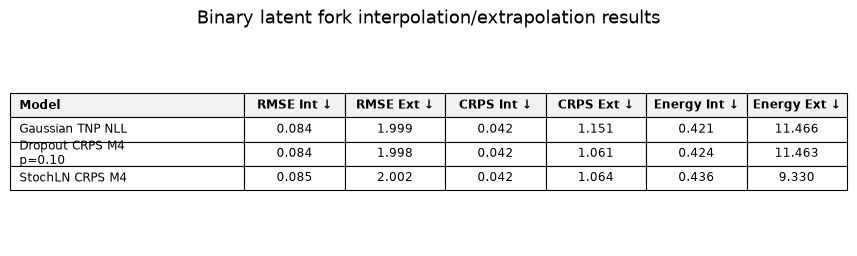

Wrote: /scratch2/ij292/tnp-crps/results/synthetic_1d/binary_latent_fork_eval/binary_latent_fork_inter_extra_table.png
Wrote: /scratch2/ij292/tnp-crps/results/synthetic_1d/binary_latent_fork_eval/binary_latent_fork_inter_extra_table.pdf


In [12]:
# Interpolation / extrapolation split table:
# Model | RMSE Int | RMSE Ext | CRPS Int | CRPS Ext | Energy Int | Energy Ext

split_metrics = pd.read_csv(metrics_path)

split_metrics = split_metrics[
    (split_metrics["context_bucket"] == "all")
    & (split_metrics["region"].isin(["interpolation", "extrapolation"]))
].copy()

print("Split table source shape:", split_metrics.shape)
display(split_metrics)

assert split_metrics.shape[0] == 6, (
    "Expected 6 rows: 3 models × 2 regions. "
    f"Got {split_metrics.shape[0]}"
)

split_metrics["Model"] = split_metrics["model_name"].map(MODEL_RENAME).fillna(
    split_metrics["model_name"]
)
split_metrics["Model"] = pd.Categorical(
    split_metrics["Model"],
    categories=MODEL_ORDER,
    ordered=True,
)

region_label = {
    "interpolation": "Int",
    "extrapolation": "Ext",
}
split_metrics["Region"] = split_metrics["region"].map(region_label)

metric_map = {
    "rmse_pooled": "RMSE",
    "crps": "CRPS",
    "energy_score": "Energy",
}

rows = []

for model in MODEL_ORDER:
    row = {"Model": model}
    model_df = split_metrics[split_metrics["Model"] == model]

    for metric_col, metric_label in metric_map.items():
        for region in ["Int", "Ext"]:
            value = model_df.loc[model_df["Region"] == region, metric_col]
            if len(value) != 1:
                raise ValueError(
                    f"Expected one value for model={model}, metric={metric_col}, region={region}. "
                    f"Got {len(value)}."
                )
            row[f"{metric_label} {region} ↓"] = float(value.iloc[0])

    rows.append(row)

split_table_df = pd.DataFrame(rows)

for col in split_table_df.columns:
    if col != "Model":
        split_table_df[col] = split_table_df[col].map(lambda x: f"{float(x):.3f}")

display(split_table_df)


def save_split_table_png_pdf(
    table_df,
    *,
    title="Binary latent fork interpolation/extrapolation results",
    output_stem="binary_latent_fork_inter_extra_table",
):
    n_rows, n_cols = table_df.shape

    fig_width = 10.8
    fig_height = 1.45 + 0.42 * n_rows

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")
    ax.set_title(title, fontsize=13, pad=10)

    model_col_width = 0.28
    remaining_width = 1.0 - model_col_width
    metric_col_width = remaining_width / (n_cols - 1)
    col_widths = [model_col_width] + [metric_col_width] * (n_cols - 1)

    tbl = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        colWidths=col_widths,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.4)
    tbl.scale(1.0, 1.45)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("black")
        cell.set_linewidth(0.8)

        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor("#f2f2f2")

        if col == 0:
            cell.set_text_props(ha="left")
            cell.PAD = 0.04

    png_path = EVAL_DIR / f"{output_stem}.png"
    pdf_path = EVAL_DIR / f"{output_stem}.pdf"

    fig.savefig(png_path, dpi=300, bbox_inches="tight", pad_inches=0.12)
    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.12)
    plt.show()

    print("Wrote:", png_path)
    print("Wrote:", pdf_path)


save_split_table_png_pdf(split_table_df)